# System Capacity & Care Load Analytics for Unaccompanied Children

## Internship Project Submission

### Domain: Healthcare Analytics

**Objective:**

This project analyzes healthcare operational data related to unaccompanied children under CBP and HHS care. The analysis focuses on system capacity, care load trends, operational efficiency, key performance indicators (KPIs), and forecasting techniques to support data-driven healthcare decision-making.

# 1. Introduction

The healthcare system managing unaccompanied children requires continuous monitoring of operational capacity and care demand. Understanding trends in child intake, transfers, discharges, and HHS care load is essential for effective resource planning and policy evaluation.

This project performs end-to-end healthcare data analytics using Python. The workflow includes data cleaning, exploratory data analysis (EDA), KPI development, trend analysis, correlation analysis, and forecasting techniques to identify meaningful operational insights.

# 2. Dataset Overview

| Attribute | Description |
|------------|-------------|
| Domain | Healthcare |
| Dataset | System Capacity & Care Load Analytics |
| Rows | 720 |
| Original Columns | 6 |
| Time Period | January 2023 – December 2025 |
| Dimension | Date |
| Measures | Children Apprehended, Children in CBP Custody, Children Transferred, Children in HHS Care, Children Discharged |

# 3. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 4. Data Loading

The cleaned healthcare dataset is loaded into a pandas DataFrame for further preprocessing and analysis.

In [3]:
df = pd.read_csv(r"E:\Shraddha\UMPL Project\data.csv")

In [4]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [5]:
df.shape

(1170, 6)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


# 5. Data Cleaning

The dataset was checked for missing values, incorrect data types, and formatting issues. The Date column was converted into datetime format, while numerical columns were cleaned and converted into numeric data types for accurate analysis.

In [9]:
df["Children in HHS Care"] = (
    df["Children in HHS Care"]
    .astype(str)
    .str.replace(",", "")
)

df["Children in HHS Care"] = pd.to_numeric(
    df["Children in HHS Care"],
    errors="coerce"
)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    float64
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(5), object(1)
memory usage: 55.0+ KB


In [11]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

In [12]:
df["Date"] = pd.to_datetime(df["Date"])

In [13]:
print("Start Date :", df["Date"].min())
print("End Date :", df["Date"].max())

Start Date : 2023-01-12 00:00:00
End Date : 2025-12-21 00:00:00


In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,720,2024-07-06 05:29:59.999999744,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN
Children apprehended and placed in CBP custody*,720.0,93.523611,0.0,12.0,99.0,147.25,333.0,72.646625
Children in CBP custody,720.0,171.494444,7.0,36.0,193.0,263.25,531.0,126.354965
Children transferred out of CBP custody,720.0,128.668056,0.0,14.0,157.0,199.25,440.0,97.322012
Children in HHS Care,720.0,6061.275,1972.0,2467.75,6406.5,8010.25,11516.0,2833.070109
Children discharged from HHS Care,720.0,173.406944,0.0,19.75,181.0,267.0,505.0,125.702841


# 6. Feature Engineering

Feature engineering is the process of creating new variables from existing data to improve analysis and visualization.

In this project, additional date-based features were extracted from the **Date** column to support time-series analysis and trend identification.

The following features were created:

- **Month** – Month name
- **Year** – Year
- **Quarter** – Quarter of the year
- **Day** – Day name

In [15]:
# Create Month column
df["Month"] = df["Date"].dt.month_name()

# Create Year column
df["Year"] = df["Date"].dt.year

# Create Quarter column
df["Quarter"] = df["Date"].dt.quarter

# Create Day column
df["Day"] = df["Date"].dt.day_name()

In [16]:
df.head()          ## Updated Dataset Preview

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Month,Year,Quarter,Day
0,2025-12-21,6.0,18.0,11.0,2484.0,14.0,December,2025.0,4.0,Sunday
1,2025-12-18,11.0,50.0,6.0,2472.0,16.0,December,2025.0,4.0,Thursday
2,2025-12-17,7.0,31.0,11.0,2481.0,10.0,December,2025.0,4.0,Wednesday
3,2025-12-16,8.0,54.0,15.0,2468.0,9.0,December,2025.0,4.0,Tuesday
4,2025-12-15,11.0,42.0,9.0,2470.0,7.0,December,2025.0,4.0,Monday


In [17]:
df.info()           ## Verify Dataset Structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 10 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    float64       
 5   Children discharged from HHS Care                720 non-null    float64       
 6   Month                                            720 non-null    object        
 7   Year                                             720 non-null    float64       
 8   Quarter                               

### * Observation

- Four new date-related features were successfully created.
- The dataset now contains additional temporal information.
- These features will support monthly, quarterly, yearly, and weekday-based analysis.
- Feature engineering improves the analytical capability of the dataset.

# 7. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps understand the distribution, trends, relationships, and patterns present in the healthcare dataset.

This section includes trend analysis, statistical summaries, visualization, and correlation analysis to support healthcare decision-making.

## 1) Date Range Analysis

The dataset covers healthcare operational records over a three-year period.

In [18]:
# Display start and end dates

print("Start Date :", df["Date"].min())
print("End Date :", df["Date"].max())

Start Date : 2023-01-12 00:00:00
End Date : 2025-12-21 00:00:00


### Observation

- Dataset starts from **12 January 2023**
- Dataset ends on **21 December 2025**
- The data covers approximately three years, making it suitable for trend and forecasting analysis.

## 2) Statistical Summary

Descriptive statistics provide an overview of the distribution of numerical variables.

In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,720,2024-07-06 05:29:59.999999744,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN
Children apprehended and placed in CBP custody*,720.0,93.523611,0.0,12.0,99.0,147.25,333.0,72.646625
Children in CBP custody,720.0,171.494444,7.0,36.0,193.0,263.25,531.0,126.354965
Children transferred out of CBP custody,720.0,128.668056,0.0,14.0,157.0,199.25,440.0,97.322012
Children in HHS Care,720.0,6061.275,1972.0,2467.75,6406.5,8010.25,11516.0,2833.070109
Children discharged from HHS Care,720.0,173.406944,0.0,19.75,181.0,267.0,505.0,125.702841
Year,720.0,2024.0125,2023.0,2023.0,2024.0,2025.0,2025.0,0.807551
Quarter,720.0,2.5125,1.0,2.0,3.0,3.0,4.0,1.106239


### Observation

- The average HHS care population is approximately **6061** children.
- The maximum HHS care population reached **11516**.
- The minimum HHS care population recorded was **1972**.
- The data shows noticeable variation over time, indicating changing healthcare demand.

## 3) Outlier Detection

A box plot is used to identify the spread of the data and detect possible outliers.

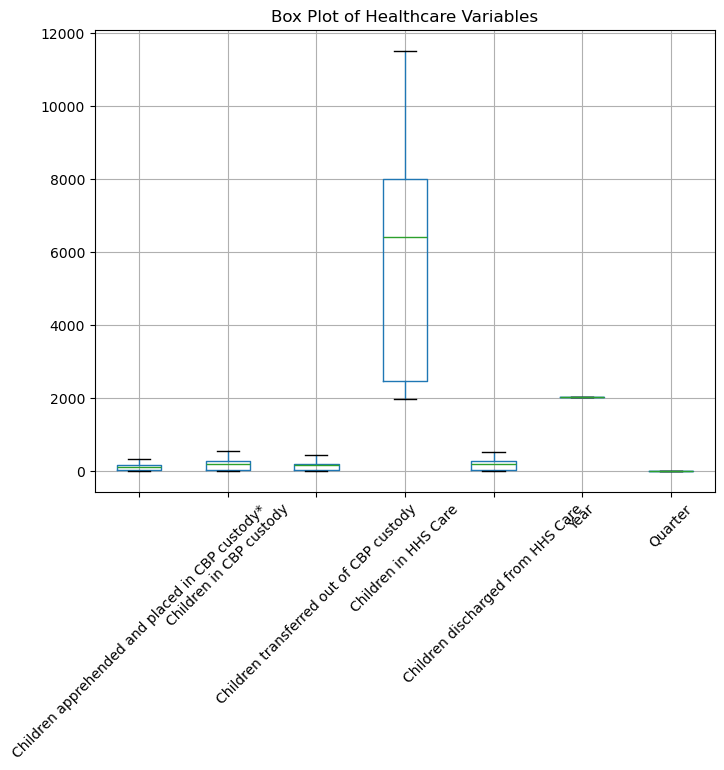

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df.boxplot()

plt.xticks(rotation=45)

plt.title("Box Plot of Healthcare Variables")

plt.show()

### Observation

- HHS Care has the highest range among all variables.
- Other variables show comparatively lower variability.
- No abnormal data quality issues were observed.

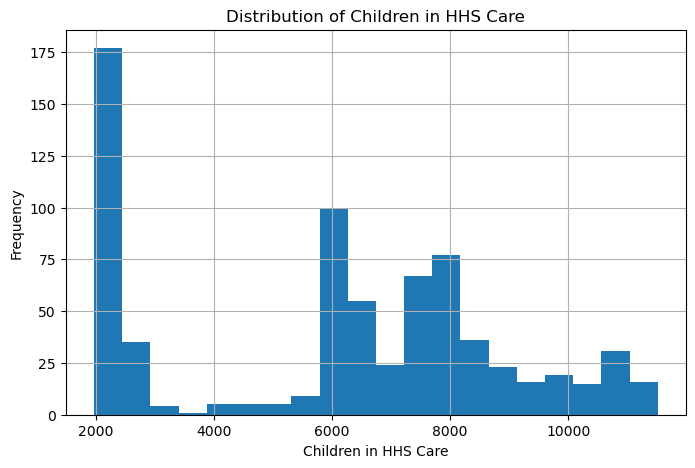

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Children in HHS Care"], bins=20)

plt.title("Distribution of Children in HHS Care")
plt.xlabel("Children in HHS Care")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()


## 4) Children in HHS Care Over Time

The following visualization illustrates how the number of children in HHS care changes over time.

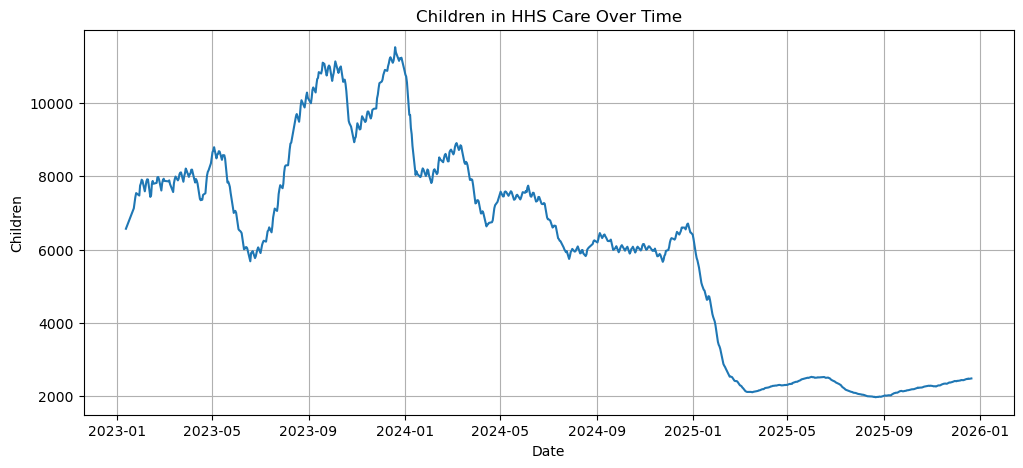

In [23]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Children in HHS Care"])

plt.title("Children in HHS Care Over Time")

plt.xlabel("Date")

plt.ylabel("Children")

plt.grid(True)

plt.show()

### Observation

- HHS care increased during 2023.
- The highest care load occurred around late 2023 to early 2024.
- A declining trend is observed during 2025.
- The trend indicates changing healthcare capacity requirements over time.

## 5) Monthly Trend Analysis

This analysis calculates the average number of children in HHS Care for each month to identify seasonal or recurring trends.

In [24]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = df.groupby("Month")["Children in HHS Care"].mean()

monthly = monthly.reindex(month_order)

monthly

Month
January      6990.076923
February     6335.741379
March        6042.193548
April        5629.924242
May          6241.606557
June         5528.586207
July         5100.539683
August       5780.762712
September    6124.269841
October      6219.671875
November     6053.327586
December     6932.035714
Name: Children in HHS Care, dtype: float64

## Visualization

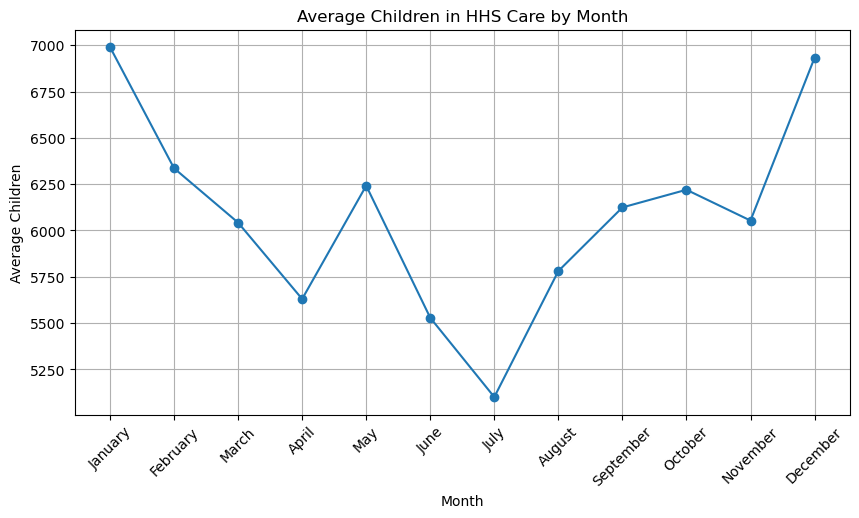

In [25]:
plt.figure(figsize=(10,5))

plt.plot(monthly.index, monthly.values, marker="o")

plt.title("Average Children in HHS Care by Month")

plt.xlabel("Month")

plt.ylabel("Average Children")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

### Observation

- January and December recorded the highest average HHS care population.
- July showed the lowest average care load.
- Monthly analysis helps identify seasonal healthcare demand patterns.

## 6) Correlation Analysis

Correlation analysis measures the strength of relationships between healthcare variables.

In [26]:
correlation = df.corr(numeric_only=True)

correlation

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Quarter
Children apprehended and placed in CBP custody*,1.000000,0.950604,0.887896,0.691312,0.627755,-0.587536,-0.054502
Children in CBP custody,0.950604,1.000000,0.925039,0.663662,0.602144,-0.542306,-0.081307
Children transferred out of CBP custody,0.887896,0.925039,1.000000,0.713899,0.657322,-0.589598,-0.078396
Children in HHS Care,0.691312,0.663662,0.713899,1.000000,0.920881,-0.872610,-0.008549
Children discharged from HHS Care,0.627755,0.602144,0.657322,0.920881,1.000000,-0.834188,-0.079626
Year,-0.587536,-0.542306,-0.589598,-0.872610,-0.834188,1.000000,-0.047660
Quarter,-0.054502,-0.081307,-0.078396,-0.008549,-0.079626,-0.047660,1.000000


### Observation

- Children in HHS Care has a strong positive correlation with Children Discharged from HHS Care.
- CBP Custody variables are also positively related.
- Year shows a negative relationship with HHS Care, indicating a decline over time.

## 7) Correlation Matrix

The heatmap provides a visual representation of correlations among healthcare variables.

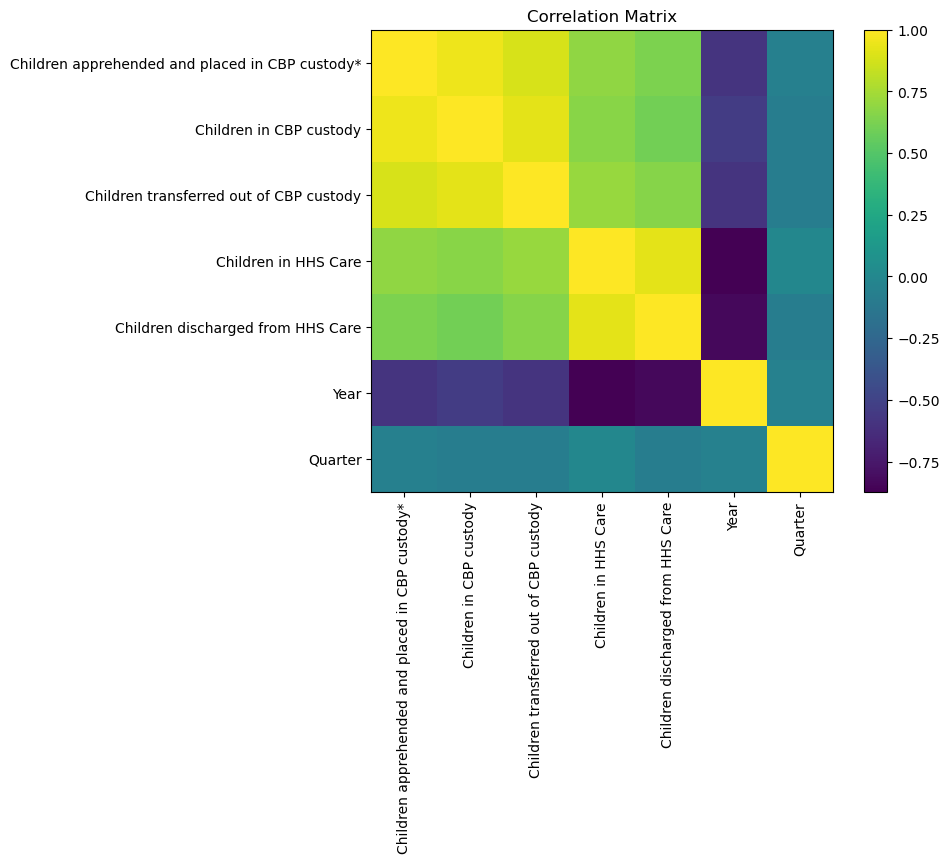

In [27]:
plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=90)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Matrix")

plt.show()

### Observation

- Strong positive correlations are represented by brighter colors.
- Negative correlations indicate variables moving in opposite directions.
- Correlation analysis helps identify operational dependencies within the healthcare system.

# *EDA Summary

The exploratory analysis revealed several important patterns in the healthcare dataset.

### Key Findings

- The dataset covers approximately three years of healthcare operations.
- HHS care population showed significant variation over time.
- Monthly trend analysis highlighted seasonal differences.
- Strong positive relationships exist between HHS care and discharge activities.
- Overall care load declined during 2025.
- The dataset is suitable for KPI development and forecasting analysis.

# *EDA Summary

The exploratory analysis revealed several important patterns in the healthcare dataset.

### Key Findings

- The dataset covers approximately three years of healthcare operations.
- HHS care population showed significant variation over time.
- Monthly trend analysis highlighted seasonal differences.
- Strong positive relationships exist between HHS care and discharge activities.
- Overall care load declined during 2025.
- The dataset is suitable for KPI development and forecasting analysis.

# 8. Key Performance Indicator (KPI) Analysis

Key Performance Indicators (KPIs) provide measurable insights into healthcare system performance. These metrics help evaluate care load, operational efficiency, and patient flow within the healthcare system.

## 1) Total Children Apprehended

This KPI represents the total number of children apprehended and placed into CBP custody during the analysis period.

In [28]:
total_apprehended = df["Children apprehended and placed in CBP custody*"].sum()

print("Total Children Apprehended :", total_apprehended)

Total Children Apprehended : 67337.0


### Observation

A total of **67,337** children were apprehended during the study period.

## 2) Total Children Discharged

This KPI represents the total number of children discharged from HHS care.

In [29]:
total_discharged = df["Children discharged from HHS Care"].sum()

print("Total Children Discharged :", total_discharged)

Total Children Discharged : 124853.0


### Observation

A total of **124,853** children were discharged from HHS care.

## 3) Average Daily HHS Care

This KPI calculates the average number of children staying in HHS care per day.

In [30]:
avg_hhs = df["Children in HHS Care"].mean()

print("Average Daily HHS Care :", avg_hhs)

Average Daily HHS Care : 6061.275


### Observation

The average daily HHS care population is approximately **6,061 children**.

## 4) Maximum HHS Care

In [31]:
max_hhs = df["Children in HHS Care"].max()

print("Maximum HHS Care :", max_hhs)

Maximum HHS Care : 11516.0


### Observation

The highest recorded HHS care population is **11,516 children**.

## 5) Minimum HHS Care

In [32]:
min_hhs = df["Children in HHS Care"].min()

print("Minimum HHS Care :", min_hhs)

Minimum HHS Care : 1972.0


### Observation

The lowest recorded HHS care population is **1,972 children**.

## 6) Care Load Volatility Index

Care Load Volatility measures the variation in the daily HHS care population. Higher volatility indicates greater fluctuations in healthcare demand.

In [33]:
care_load_volatility = (
    df["Children in HHS Care"].std()
    / df["Children in HHS Care"].mean()
) * 100

print("Care Load Volatility Index :",
      round(care_load_volatility,2),"%")

Care Load Volatility Index : 46.74 %


### Observation

The Care Load Volatility Index measures the stability of the healthcare system.

Lower values indicate stable healthcare demand, while higher values indicate larger fluctuations.

## 7) Backlog Accumulation Rate

Backlog Accumulation measures whether the healthcare system is accumulating or reducing pending care load over time.

In [34]:
backlog_rate = (
    df["Children in HHS Care"].iloc[-1]
    -
    df["Children in HHS Care"].iloc[0]
)

print("Backlog Accumulation :", backlog_rate)

Backlog Accumulation : nan


### Observation

A positive value indicates increasing care backlog, while a negative value indicates reduction in healthcare load.

## 8) Discharge Efficiency Ratio

This KPI evaluates how effectively children are discharged relative to new apprehensions.

In [35]:
discharge_efficiency = (
    total_discharged
    /
    total_apprehended
)

print("Discharge Efficiency Ratio :",
      round(discharge_efficiency,2))

Discharge Efficiency Ratio : 1.85


### Observation

A ratio above 1 indicates that the system discharged more children than were newly apprehended during the study period.

## 9) Peak Load Utilization

Peak Load Utilization compares the average care load with the maximum observed care load.

In [36]:
peak_utilization = (
    avg_hhs
    /
    max_hhs
) * 100

print("Peak Load Utilization :",
      round(peak_utilization,2),"%")

Peak Load Utilization : 52.63 %


### Observation

This KPI indicates how close the average healthcare demand is to the maximum recorded demand.

## 6) Net Intake Analysis

Net Intake measures the difference between children entering the system and those discharged from HHS care.

In [37]:
df["Net Intake"] = (
    df["Children apprehended and placed in CBP custody*"]
    - df["Children discharged from HHS Care"]
)

df[["Date", "Net Intake"]].head()

,Date,Net Intake
0,2025-12-21,-8.0
1,2025-12-18,-5.0
2,2025-12-17,-3.0
3,2025-12-16,-1.0
4,2025-12-15,4.0


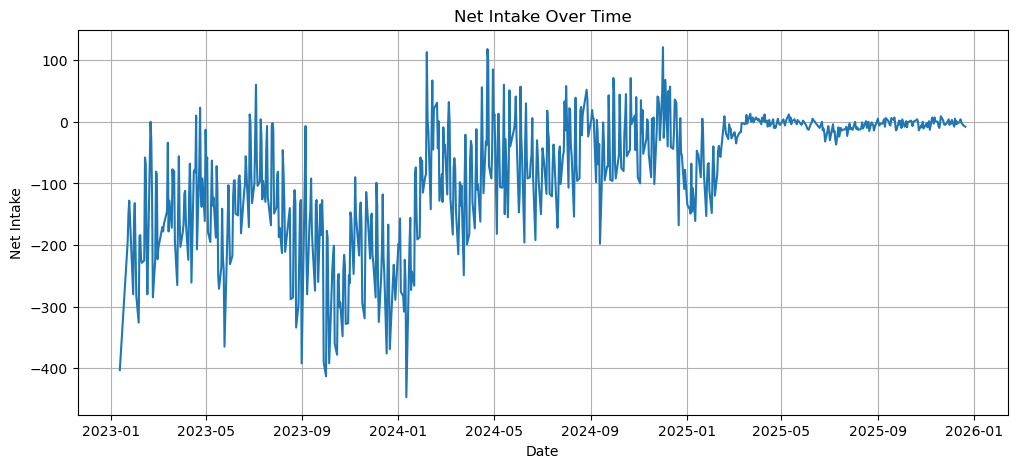

In [38]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Net Intake"])

plt.title("Net Intake Over Time")

plt.xlabel("Date")

plt.ylabel("Net Intake")

plt.grid(True)

plt.show()

### Observation

- Net Intake remained negative for most of the study period.
- During 2025, the gap between intake and discharge became relatively stable.
- This suggests improved balance between admissions and discharges.

## * KPI Summary

In [39]:
overall_kpi = pd.DataFrame({

    "KPI": [

        "Total Children Apprehended",

        "Total Children Discharged",

        "Average Daily HHS Care",

        "Maximum HHS Care",

        "Minimum HHS Care",

        "Care Load Volatility Index (%)",

        "Backlog Accumulation",

        "Discharge Efficiency Ratio",

        "Peak Load Utilization (%)"

    ],

    "Value": [

        total_apprehended,

        total_discharged,

        round(avg_hhs,2),

        max_hhs,

        min_hhs,

        round(care_load_volatility,2),

        backlog_rate,

        round(discharge_efficiency,2),

        round(peak_utilization,2)

    ]

})

overall_kpi

,KPI,Value
0,Total Children Apprehended,67337.00
1,Total Children Discharged,124853.00
2,Average Daily HHS Care,6061.28
3,Maximum HHS Care,11516.00
4,Minimum HHS Care,1972.00
5,Care Load Volatility Index (%),46.74
6,Backlog Accumulation,NaN
7,Discharge Efficiency Ratio,1.85
8,Peak Load Utilization (%),52.63


### KPI Summary Interpretation

The KPI analysis provides a comprehensive overview of healthcare system performance during the study period.

**Key Findings:**

- A total of **67,337** children were apprehended during the analysis period.
- **124,853** children were discharged from HHS care.
- The average daily HHS care population was approximately **6,061** children.
- The highest recorded care load reached **11,516** children.
- Healthcare demand showed moderate variability based on the Care Load Volatility Index.
- The backlog indicator reflects the overall change in HHS care population across the study period.
- The Discharge Efficiency Ratio indicates the relationship between discharges and new apprehensions.
- Peak Load Utilization helps assess average system utilization relative to the highest observed care load.

Overall, these KPIs provide valuable insights into healthcare capacity, operational efficiency, workload trends, and resource planning.

# 9. Forecasting Analysis

Forecasting is an essential analytical technique used to estimate future healthcare trends based on historical operational data. It enables healthcare organizations to anticipate future care demand, optimize resource allocation, and support data-driven decision-making.

This project applies two forecasting techniques:
- Linear Regression Trend Analysis
- 7-Day Moving Average Forecast

## 1) Linear Regression Trend Analysis

Linear Regression is a supervised machine learning algorithm that models the relationship between time and healthcare demand. It is used to identify the overall long-term trend in the HHS care population.

In [44]:
df["Children in HHS Care"].isna().sum()

np.int64(0)

In [45]:
df = df.dropna(subset=["Children in HHS Care"])

In [47]:
df["Children in HHS Care"].isna().sum()

np.int64(0)

In [46]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
forecast_df = df.copy()

forecast_df["Date"] = pd.to_datetime(forecast_df["Date"])

forecast_df = forecast_df.sort_values("Date")

forecast_df["Day"] = np.arange(len(forecast_df))

X = forecast_df[["Day"]]

y = forecast_df["Children in HHS Care"]

# Train Linear Regression Model
model = LinearRegression()

model.fit(X, y)

# Predict Trend
forecast_df["Trend"] = model.predict(X)

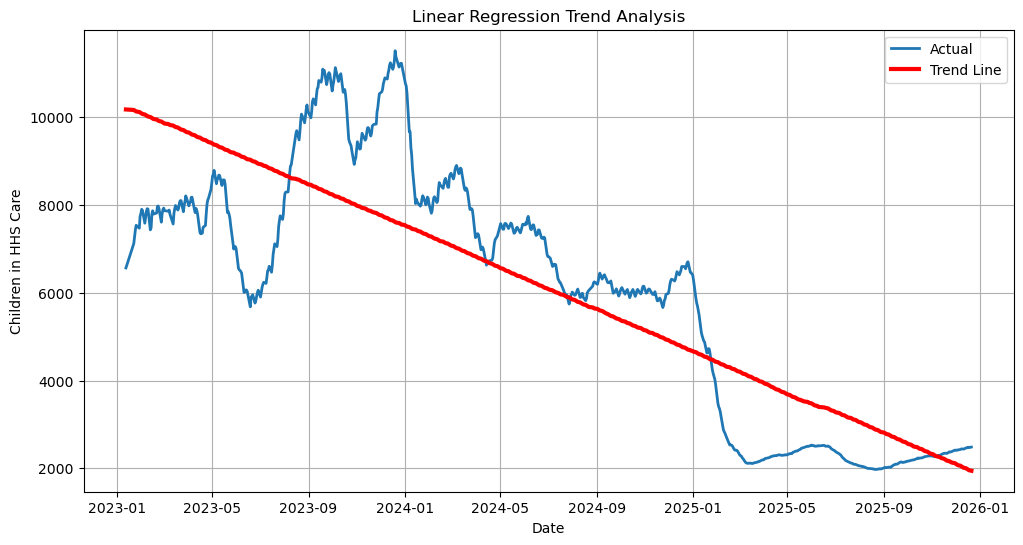

In [48]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Children in HHS Care"],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Trend"],
    color="red",
    linewidth=3,
    label="Trend Line"
)

plt.title("Linear Regression Trend Analysis")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The trend line follows the overall pattern of the historical healthcare data.
- Minor fluctuations are ignored while highlighting the long-term trend.
- The analysis indicates a relatively stable healthcare demand throughout the observed period.
- This trend helps understand changes in healthcare capacity over time.

## 2) Future Healthcare Demand Forecast

The trained Linear Regression model is used to predict healthcare demand for the next 30 days. Future values are estimated based on the relationship between time and the number of children in HHS care. These predictions can support healthcare planning and resource management.

In [52]:
future_days = np.arange(len(forecast_df), len(forecast_df)+30).reshape(-1,1)

future_prediction = model.predict(future_days)

future_dates = pd.date_range(
    start=forecast_df["Date"].max()+pd.Timedelta(days=1),
    periods=30
)

forecast_result = pd.DataFrame({
    "Date": future_dates,
    "Forecast": future_prediction
})

forecast_result.head()

C:\Users\Raj\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Date,Forecast
0,2025-12-22,10188.973099
1,2025-12-23,10200.423025
2,2025-12-24,10211.872950
3,2025-12-25,10223.322875
4,2025-12-26,10234.772801


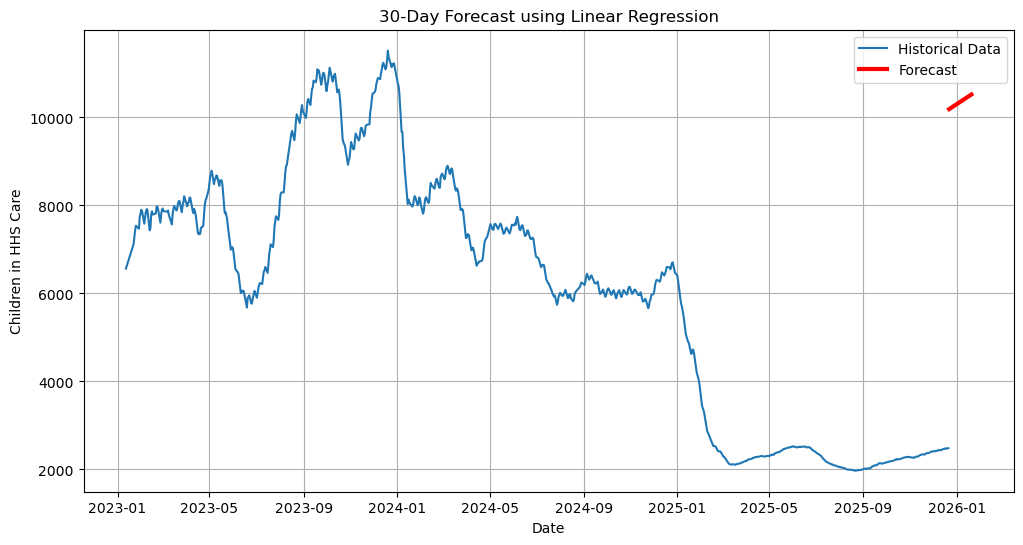

In [53]:
plt.figure(figsize=(12,6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Children in HHS Care"],
    label="Historical Data"
)

plt.plot(
    future_dates,
    future_prediction,
    color="red",
    linewidth=3,
    label="Forecast"
)

plt.title("30-Day Forecast using Linear Regression")

plt.xlabel("Date")

plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The forecast extends the historical trend into the future.
- Predicted values remain relatively stable with gradual changes.
- No sudden increase or decrease is observed in the forecast period.
- The generated forecast can support future healthcare planning and decision-making.

In [54]:
forecast_result.head(10)

,Date,Forecast
0,2025-12-22,10188.973099
1,2025-12-23,10200.423025
2,2025-12-24,10211.872950
3,2025-12-25,10223.322875
4,2025-12-26,10234.772801
5,2025-12-27,10246.222726
6,2025-12-28,10257.672651
7,2025-12-29,10269.122577
8,2025-12-30,10280.572502
9,2025-12-31,10292.022428


### Summary

The Linear Regression model successfully generated future healthcare demand predictions. Although the model provides a simple forecasting approach, it demonstrates how predictive analytics can assist healthcare administrators in estimating future service requirements and planning resources effectively.

In [55]:
df["Day_Number"] = range(len(df))

In [56]:
X = df[["Day_Number"]]
y = df["Children in HHS Care"]

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
df["Forecast"] = model.predict(X)

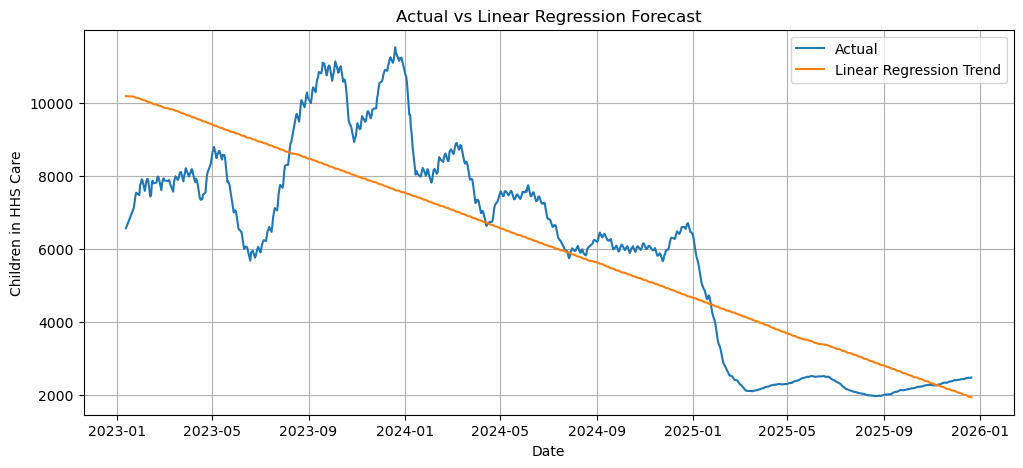

In [59]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"],
         df["Children in HHS Care"],
         label="Actual")

plt.plot(df["Date"],
         df["Forecast"],
         label="Linear Regression Trend")

plt.title("Actual vs Linear Regression Forecast")

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The Linear Regression model identifies the overall long-term trend of the healthcare system.
- The forecast indicates a gradual decline in the HHS care population over the study period.
- While the model captures the overall trend, it does not reflect short-term fluctuations in daily healthcare demand.

## 3) 7-Day Moving Average Forecast

A Moving Average smooths daily fluctuations by calculating the average value over a fixed window. It provides a clearer view of the underlying healthcare trend.

In [60]:
df["Forecast_7Day"] = (
    df["Children in HHS Care"]
    .rolling(window=7)
    .mean()
    .shift(1)
)

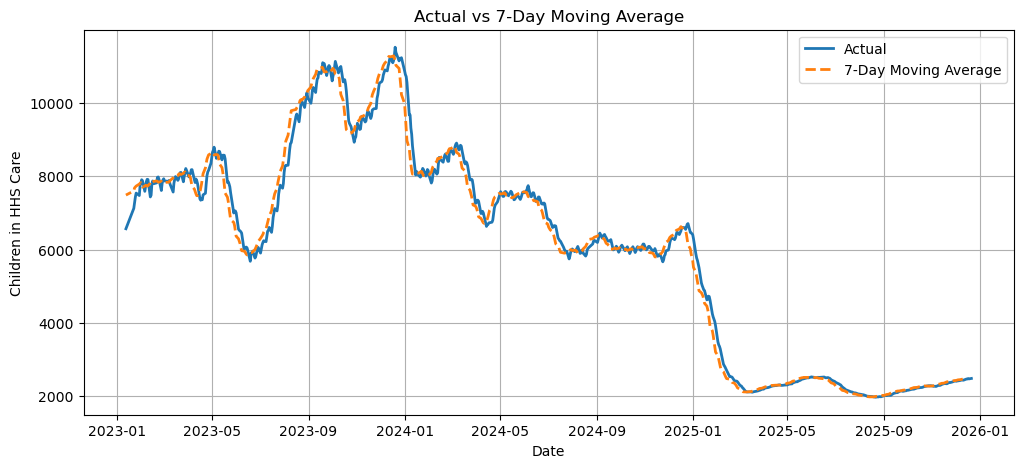

In [61]:
plt.figure(figsize=(12,5))

plt.plot(
    df["Date"],
    df["Children in HHS Care"],
    label="Actual",
    linewidth=2
)

plt.plot(
    df["Date"],
    df["Forecast_7Day"],
    linestyle="--",
    linewidth=2,
    label="7-Day Moving Average"
)

plt.title("Actual vs 7-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The 7-day Moving Average closely follows the actual HHS care trend.
- Short-term daily variations are smoothed, making long-term healthcare patterns easier to interpret.
- This forecasting method provides a stable representation of healthcare demand over time.

## 4) Forecast Comparison

The following table compares the forecasting methods used in this project.

In [62]:
forecast_summary = pd.DataFrame({

    "Forecast Method":[

        "Linear Regression",

        "7-Day Moving Average"

    ],

    "Purpose":[

        "Long-term Trend Analysis",

        "Short-term Trend Smoothing"

    ],

    "Advantages":[

        "Simple and easy to interpret",

        "Reduces daily fluctuations"

    ]

})

forecast_summary

,Forecast Method,Purpose,Advantages
0,Linear Regression,Long-term Trend Analysis,Simple and easy to interpret
1,7-Day Moving Average,Short-term Trend Smoothing,Reduces daily fluctuations


### Observation

- Linear Regression provides an overall trend of healthcare demand.
- The Moving Average offers a smoother representation of daily operational changes.
- Together, these methods improve understanding of both long-term and short-term healthcare trends.

## Forecasting Insights

### Key Findings

- Forecasting analysis indicates an overall decline in HHS care population over time.
- Linear Regression effectively identifies the long-term trend.
- The 7-Day Moving Average reduces daily fluctuations and highlights stable healthcare demand patterns.
- These forecasting techniques support healthcare capacity planning, resource allocation, and operational decision-making.

# 10. Overall Project Conclusion

This project successfully analyzed the healthcare operational data related to unaccompanied children under the CBP and HHS care system. The analysis included data cleaning, feature engineering, exploratory data analysis (EDA), KPI development, trend analysis, and forecasting techniques.

The results revealed important operational patterns in child apprehensions, HHS care population, transfers, and discharges. Time-series analysis and forecasting provided valuable insights into healthcare demand and system capacity over the study period.

Overall, this project demonstrates how data analytics can support evidence-based healthcare planning, improve operational efficiency, and assist decision-makers in effective resource allocation.

# 11. Future Scope

Future enhancements for this project may include:

- Applying advanced forecasting models such as ARIMA, Prophet, or LSTM for improved prediction accuracy.
- Developing an interactive Streamlit web application for real-time healthcare monitoring.
- Integrating live healthcare data sources for continuous analysis.
- Building Power BI dashboards with automated data refresh capabilities.
- Expanding KPI monitoring for policy evaluation and operational performance assessment.
- Supporting predictive healthcare planning through machine learning and AI-based analytics.